### End to end optimization of sequential generation

This notebook should implement the line of optimizations Lcomp->minLA ordering->sequential generation algorithm(with enhanced two qubit gate count)

Lcomp:
><p>input: graph</p>
><p>output: sequence of local complementations</p>

minLA:
><p>input: graph, initial order</p>
><p>ouput: vertex order based on the inital ordering</p>

sequential generation algorithm:
><p>input: stabilizer tableau corresponding to the graph+ordering</p>
><p>output: inverse circuit operations

In [3]:
import numpy as np
import networkx as nx
from tqdm.notebook import tqdm
import sys 
sys.path.insert(0, '..')
from lib.circuitSolver import *
from lib.generate_graph import *
from lib.tableau import *
from lib.LC_edge_reduction import *
from optimization_script import *

Define a specific graph to test all functions on (a member of the LC-orbit 78 with a random order)

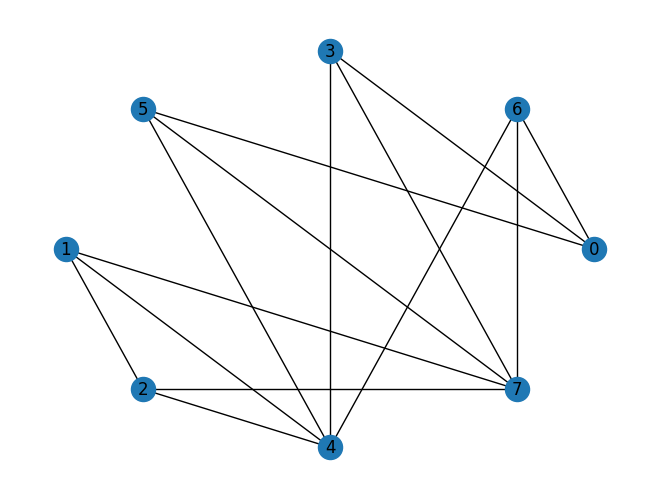

In [4]:
G_in = nx.Graph()
G_in.add_edges_from([(0,6),(0,3),(0,5),(1,2),(1,4),(1,7),(2,4),(2,7),(3,4),(3,7),(4,5),(4,6),(5,7),(6,7)])
input_adj = nx.adjacency_matrix(G_in,nodelist=range(0,7)).toarray()
G=G_in.copy()
nx.draw(G, pos=nx.circular_layout(G),with_labels=True)
plt.show()

Reduce the number of edges by local complementation (exhaustive search can be used for small graphs)

14
[6, 7, 4, 7, 0, 2, 7, 3]
reduced graph number of edges: 8


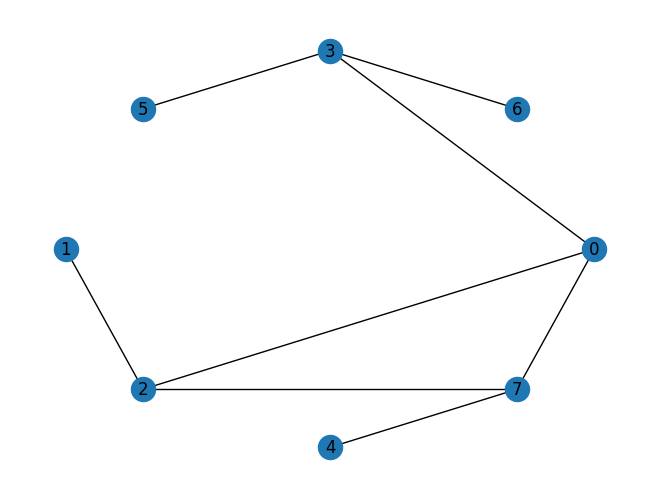

In [5]:
print(G.number_of_edges())
LCR = LCReduction(G)
LCR.edge_reduction(with_increase=True)
LC_sequence = LCR.get_path()
print(LC_sequence)
for LC in LC_sequence:
    G = GraphstateGenerator.local_complementation(G,LC)

print('reduced graph number of edges:', G.number_of_edges())
nx.draw(G, pos=nx.circular_layout(G),with_labels=True)
plt.show()

Now pass the adjacency matrix into simulated annealing and reorder the adjacency matrix

c:\Users\NilsOttink\OneDrive - Quandela\Documents\photonic-graphstate-generator\examples\..\lib\generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


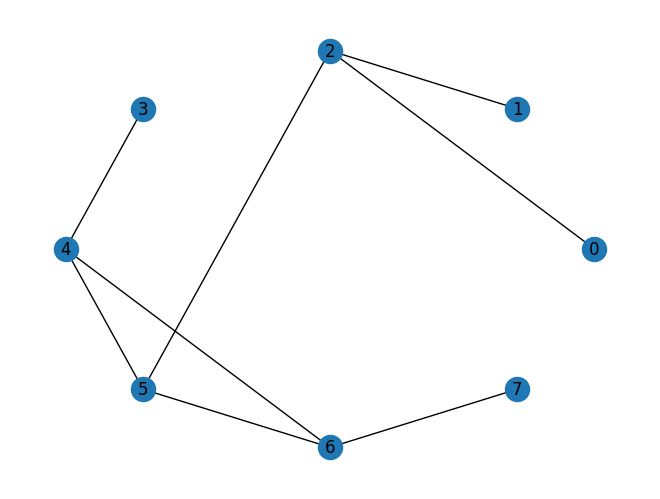

In [6]:
Gamma = nx.adjacency_matrix(G,nodelist=range(G.number_of_nodes())).toarray()
ordering, _ = GraphstateGenerator.minLa_sim_anneal(G,list(range(G.number_of_nodes())),1000,0.6,5000)
new_adjacency = nx.adjacency_matrix(G,nodelist=ordering).toarray()
H = nx.Graph(new_adjacency)
nx.draw(H, pos=nx.circular_layout(H),with_labels=True)
plt.show()

Circuit generates correct graph


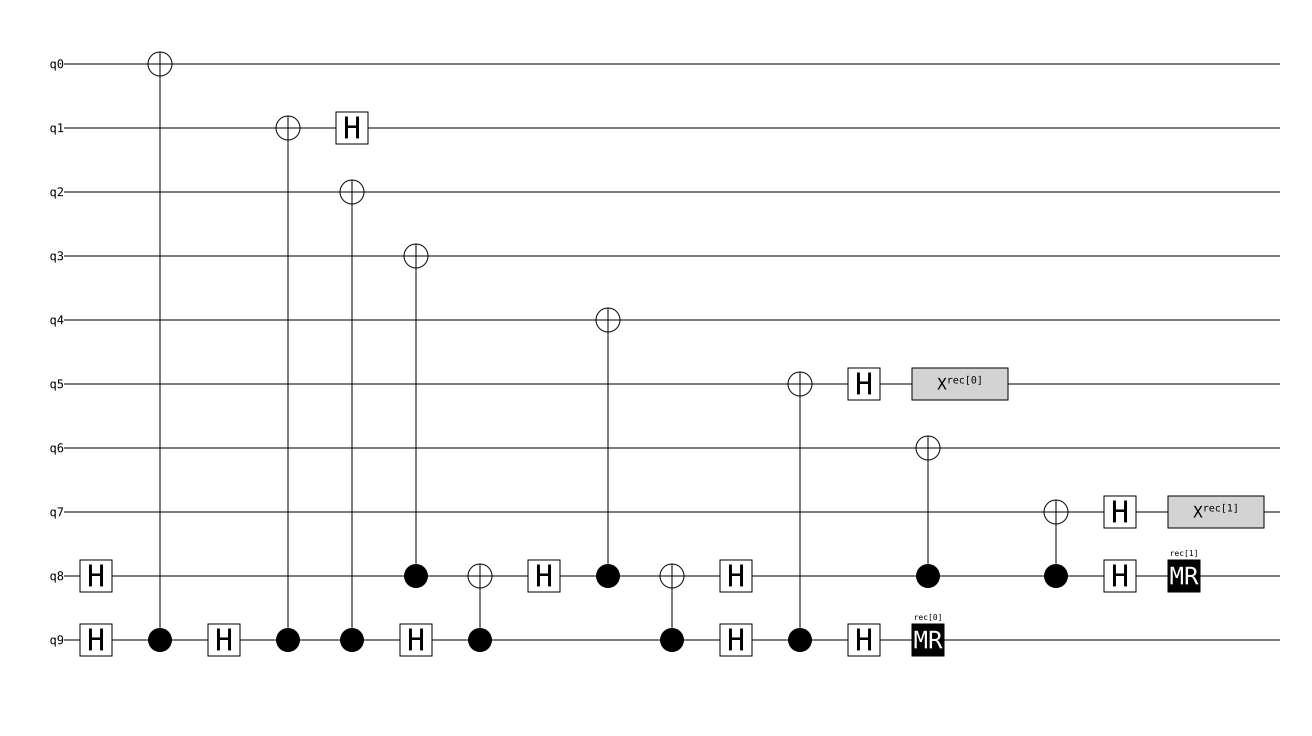

In [7]:
tableau = stabTableau(GraphstateGenerator.get_tableau_from_adj(new_adjacency))
ops,num_cnots = algorithm(tableau,optimize=True, return_num_cnots=True)
circuit = generationSequence(ops)
check_circuit(circuit,pauliStrings=tableau.pauliStrings0)
circuit.diagram('timeline-svg')

Compare to original graph emission

Circuit generates correct graph


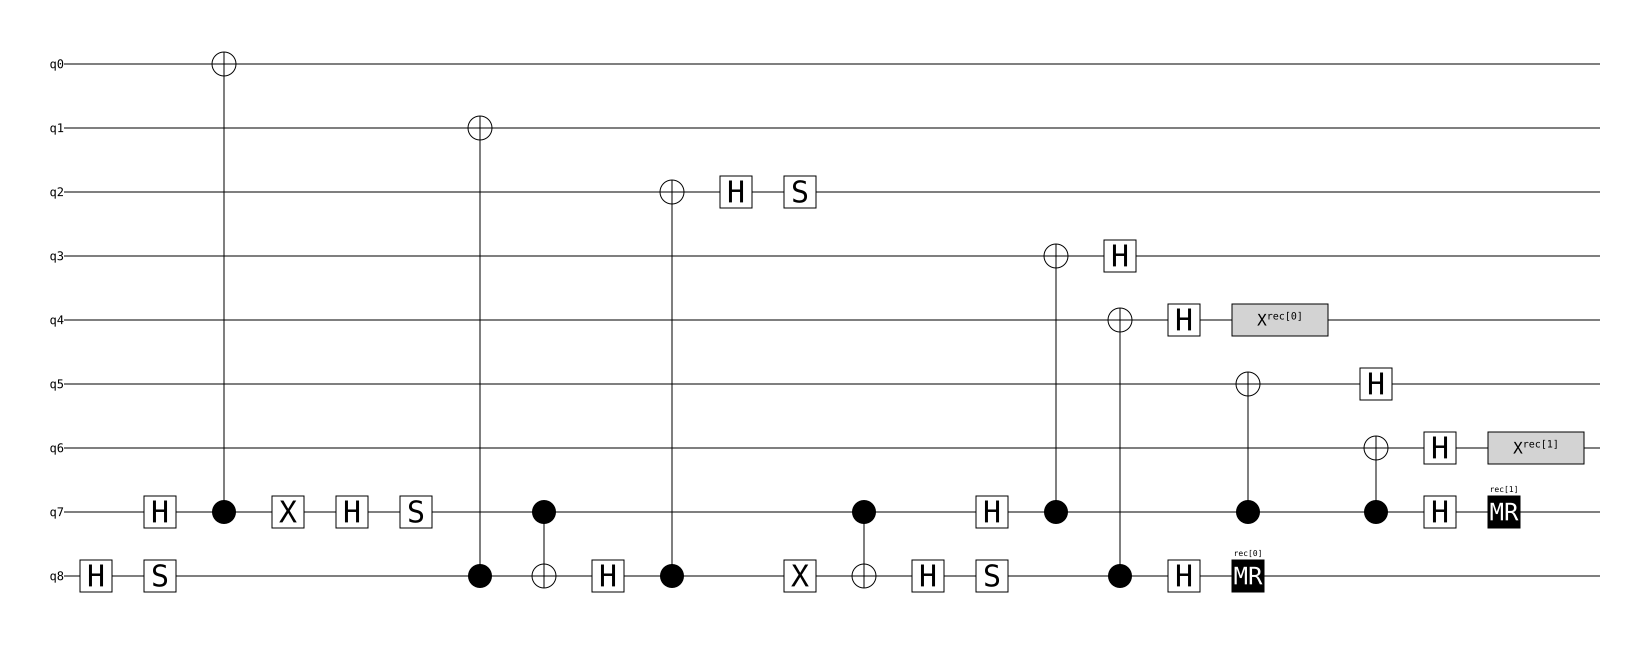

In [10]:
tableau = stabTableau(GraphstateGenerator.get_tableau_from_adj(input_adj))
ops,num_cnots = algorithm(tableau,optimize=True, return_num_cnots=True)
circuit = generationSequence(ops)
check_circuit(circuit,pauliStrings=tableau.pauliStrings0)
circuit.diagram('timeline-svg')

All the above steps are compressed into a new function (may look different because of new LC and minLA)

In [11]:
G_in = nx.Graph()
G_in.add_edges_from([(0,6),(0,3),(0,5),(1,2),(1,4),(1,7),(2,4),(2,7),(3,4),(3,7),(4,5),(4,6),(5,7),(6,7)])

c:\Users\NilsOttink\OneDrive - Quandela\Documents\photonic-graphstate-generator\examples\..\lib\generate_graph.py:133: RuntimeWarning: overflow encountered in divide
  if next_cost < current_cost or random.random() < np.exp((current_cost - next_cost)/temperature):


Circuit generates correct graph
[2, 2, 12, [4, 7, 2, 0, 1, 6, 5, 3], array([0, 3, 1, 3, 4, 6, 2, 3])]


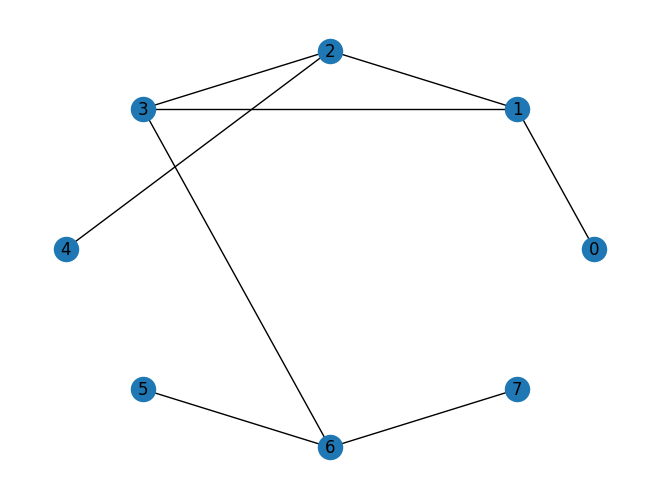

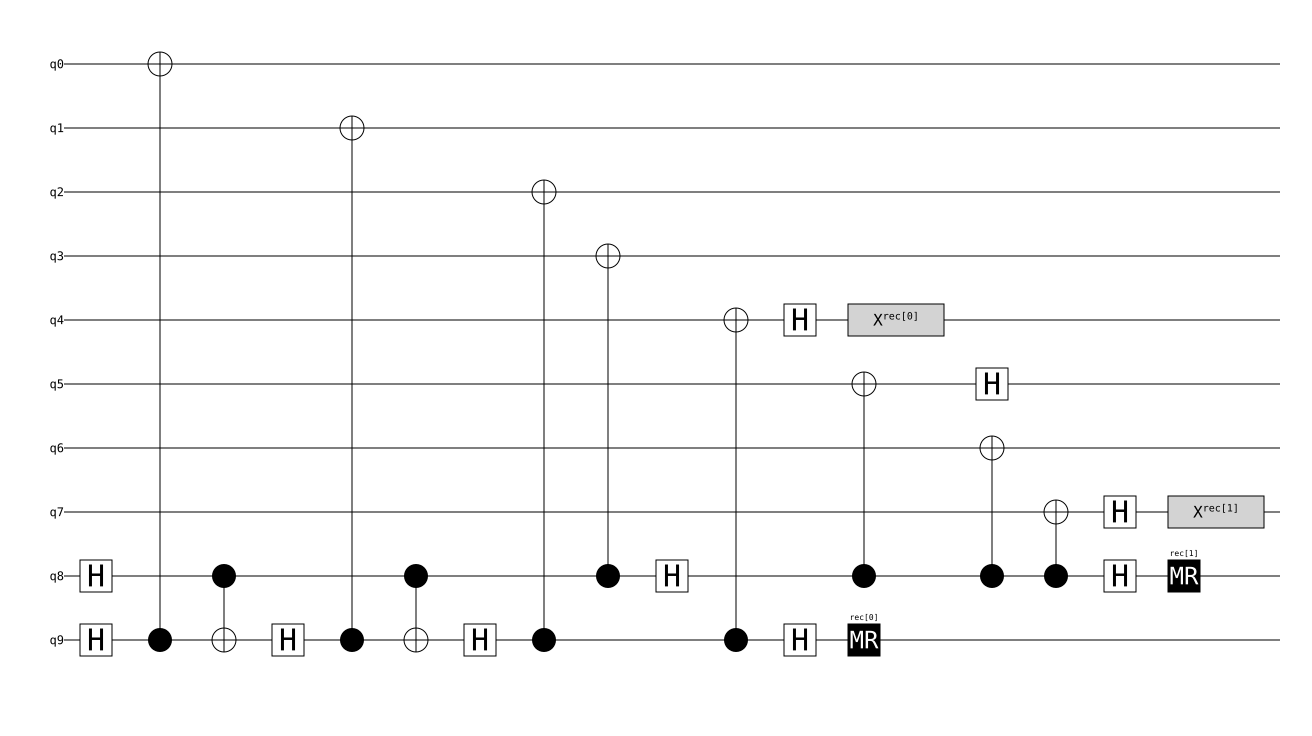

In [12]:
opt_graph, circuit, stats = run_optimization(G_in)
print(stats)
nx.draw(opt_graph,pos=nx.circular_layout(opt_graph),with_labels=True)
plt.show()
circuit.diagram('timeline-svg')

### Test of the full optimization (maybe moved to different file)
on the first LC-orbits with up to 10 qubits to compare them to the number of emitters and emitter CNOTs of the exhaustive analysis by Ghanbari et al. (https://arxiv.org/abs/2401.00635).</p>
To generate the test data: perform random local complementations and randomize the node labels (emission order) on the LC-class representative

In [2]:
import csv
unique_classes = []
with open('data\combined_classes.txt','r') as file:
    reader = csv.reader(file, delimiter='\t')
    for row in reader:
        row[-2] = row[-2].replace(')(',',')
        row[-2] = row[-2].replace('(','')
        row[-2] = row[-2].replace(')','')
        row[-2] = row[-2].replace('-',',')
        edgelist = np.fromstring(row[-2],dtype=int,sep=",")
        edgelist = edgelist.reshape(len(edgelist)//2,2)
        unique_classes.append([int(row[0]),int(row[2]),edgelist])
    
    unique_classes = np.array(unique_classes,dtype=object)
    print(len(unique_classes))

3718


In [3]:
rank_width = []
linear_rank_width=[]
min_cnot = []
with open('data\entanglement_classes_upto7qubits.txt','r') as file:
    reader = csv.reader(file, delimiter=';')
    for row in reader:
        rwd = int(row[2])
        rank_width.append(rwd)
        lrw = int(row[3])
        linear_rank_width.append(lrw)
        cnots = int(row[4])
        min_cnot.append(cnots)

In [7]:
results_without_opt = []
results_cnot_opt = []
results_minLAcnot_opt = []
results_lcminLAcnot_opt = []
results_minLA_opt = []
results_lcminLA_opt = []

for i in tqdm(unique_classes[1:]):
    print(i[0])
    G = nx.Graph()
    G.add_edges_from(i[2])
    G = LCReduction.random_LC(G,10*G.number_of_nodes())
    G1 = G.copy()
    G2 = G.copy()
    G3 = G.copy()
    G4 = G.copy()
    #opt_graph, circuit, stats = run_optimization(G1,edge_reduction=False,minLA=False,opt_CNOT=False)
    #results_without_opt.append(stats)

    #opt_graph, circuit, stats = run_optimization(G2,edge_reduction=False,minLA=False,opt_CNOT=True)
    #results_cnot_opt.append(stats)
    
    # opt_graph, circuit, stats = run_optimization(G3,edge_reduction=False,minLA=True,num_LA=5,opt_CNOT=True)
    # results_minLAcnot_opt.append(stats)

    opt_graph, circuit, stats = run_optimization(G4,edge_reduction=True,minLA=True,num_LA=5,opt_CNOT=True)
    results_lcminLAcnot_opt.append(stats)

# with open('10-qubit-orbit-data.txt', 'w') as f:
#     for line in results_without_opt:
#         f.write(f"{line}\n")
#     for line in results_cnot_opt:
#         f.write(f"{line}\n")
#     for line in results_minLAcnot_opt:
#         f.write(f"{line}\n")
#     for line in results_lcminLAcnot_opt:
#         f.write(f"{line}\n")

  0%|          | 0/3717 [00:00<?, ?it/s]

2
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
3
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
4
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
5
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
6
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
7
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
8
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
9
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
10
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
11
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
12
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
13
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
14
1 inf
1 1
1 1
1 1
1 1
Circuit generates correct graph
15
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
16
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
17
2 inf
2 2
2 2
2 2
2 2
Circuit generates correct graph
18
2 inf
2 2
3 2
2 2
2 2
Circuit generates correct graph
19
3 inf
3 3
3 3
3 3
3 3
Circuit genera

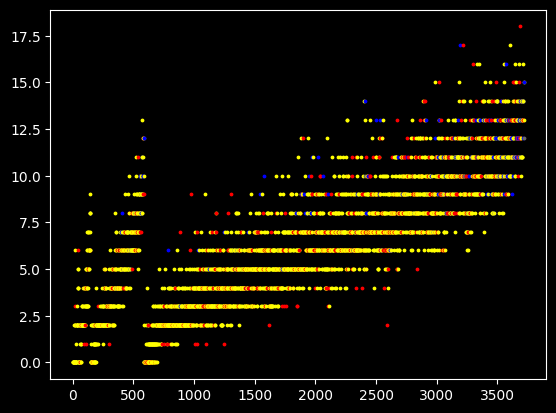

In [34]:
for i in range(3717):
    if results_lcminLAcnot_opt[i][1]<= results_cnot_opt[i][1] and results_lcminLAcnot_opt[i][1]<=results_minLAcnot_opt[i][1] and results_lcminLAcnot_opt[i][1]<=results_without_opt[i][1]:
        plt.scatter(i+2,results_lcminLAcnot_opt[i][1], c='yellow',s=3)
    elif results_minLAcnot_opt[i][1]<=results_cnot_opt[i][1] and results_minLAcnot_opt[i][1]<=results_without_opt[i][1]:
        plt.scatter(i+2,results_minLAcnot_opt[i][1], c='red',s=3)
    elif results_cnot_opt[i][1]<= results_without_opt[i][1]:
        plt.scatter(i+2,results_cnot_opt[i][1], c='blue',s=3)
    else:
        plt.scatter(i+2,results_without_opt[i][1], c='dimgrey',s=3)
#plt.plot(range(1,len(min_cnot)+1),min_cnot)

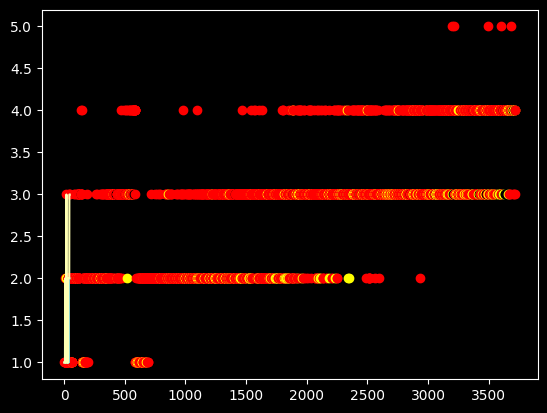

In [19]:
for i in range(3717):
    if results_lcminLAcnot_opt[i][0]<= results_cnot_opt[i][0] and results_lcminLAcnot_opt[i][0]<=results_minLAcnot_opt[i][0] and results_lcminLAcnot_opt[i][0]<=results_without_opt[i][0]:
        plt.scatter(i+2,results_lcminLAcnot_opt[i][0], c='red')
    elif results_minLAcnot_opt[i][0]<=results_cnot_opt[i][0] and results_minLAcnot_opt[i][0]<=results_without_opt[i][0]:
        plt.scatter(i+2,results_minLAcnot_opt[i][0], c='yellow')
    elif results_cnot_opt[i][0]<= results_without_opt[i][0]:
        plt.scatter(i+2,results_cnot_opt[i][0], c='black')
    else:
        plt.scatter(i+2,results_without_opt[i][0], c='blue')

#plt.plot(range(1,len(rank_width)+1),rank_width)
#plt.plot(range(1,len(linear_rank_width)+1),linear_rank_width)

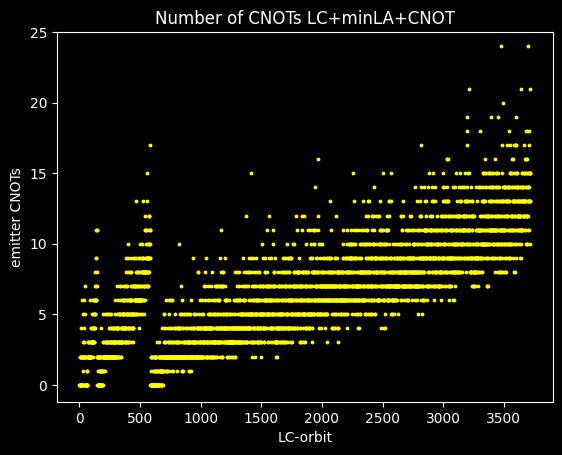

In [8]:
plt.style.use('dark_background')
for i in range(3717):
    #wo=plt.scatter(i+2,results_without_opt[i][1], c='dimgrey')
    #co=plt.scatter(i+2,results_cnot_opt[i][1], c='blue',s=3)
    # mco=plt.scatter(i+2,results_minLAcnot_opt[i][1], c='red',s=3)
    lmco = plt.scatter(i+2,results_lcminLAcnot_opt[i][1], c='yellow',s=3)
plt.xlabel('LC-orbit')
plt.ylabel('emitter CNOTs')
plt.ylim(top=25)
plt.title('Number of CNOTs LC+minLA+CNOT')
# plt.legend((wo,co,mco,lmco),('w/o', 'CNOT', 'minLA+CNOT', 'LC+minLA+CNOT'),scatterpoints = 1)
#plt.legend((mco),( 'minLA+CNOT'),scatterpoints = 1)
plt.savefig('LC_orbit_CNOTs_minLAsampling.pdf')
plt.show()

0.2718720062812463
0.27606263933403585
0.18509671063542532
0.6778211444841795
0.44905488047916076
8.207694377185902
6.867904223836427


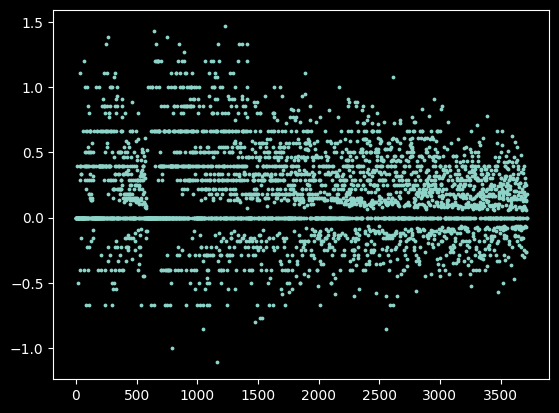

In [101]:
opt1=[]
opt2=[]
opt3=[]
opt4=[]
for i in range(3717):
    opt1.append(results_without_opt[i][1])
    opt2.append(results_cnot_opt[i][1])
    opt3.append(results_minLAcnot_opt[i][1])
    opt4.append(results_lcminLAcnot_opt[i][1])
opt1 = np.array(opt1)
opt2 = np.array(opt2)
opt3 = np.array(opt3)
opt4 = np.array(opt4)
rel_change12 = [(opt1[i]-opt2[i])/((np.abs(opt1[i])+np.abs(opt2[i]))/2) if opt1[i]!=0 and opt2[i]!=0 else 0 for i in range(3717)]
rel_change23 = [(opt2[i]-opt3[i])/((np.abs(opt2[i])+np.abs(opt3[i]))/2) if opt2[i]!=0 and opt3[i]!=0 else 0 for i in range(3717)]
rel_change34 = [(opt3[i]-opt4[i])/((np.abs(opt3[i])+np.abs(opt4[i]))/2) if opt3[i]!=0 and opt4[i]!=0 else 0 for i in range(3717)]
rel_change14 = [(opt1[i]-opt4[i])/((np.abs(opt1[i])+np.abs(opt4[i]))/2) if opt1[i]!=0 and opt4[i]!=0 else 0 for i in range(3717)]
rel_change24 = [(opt2[i]-opt4[i])/((np.abs(opt2[i])+np.abs(opt4[i]))/2) if opt2[i]!=0 and opt4[i]!=0 else 0 for i in range(3717)]
print(np.mean(rel_change12))
print(np.mean(rel_change23))
print(np.mean(rel_change34))
print(np.mean(rel_change14))
print(np.mean(rel_change24))
#plt.scatter(range(3717),rel_change23,s=3)
plt.scatter(range(3717),rel_change34,s=3)
#plt.plot(rel_change23)
#plt.plot(rel_change34)
print(np.mean(opt3))
print(np.mean(opt4))